In [1]:
import scanpy as sc
import pandas as pd
import anndata as ad
import squidpy as sq
import stlearn as st
import sopa
import matplotlib.pyplot as plt
from spatialdata._logging import logger
import spatialdata_io as spio
from spatialdata_io.experimental import from_legacy_anndata, to_legacy_anndata

from dask.distributed import Client, fire_and_forget
client = Client(processes=False)

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/stlearn/tools/microenv/cci/het.py:192: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(parallel=True, nopython=False)
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45793 instead
  warnings.warn(


In [2]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.120.128.18:45793/status,
Dashboard: http://10.120.128.18:45793/status,Workers: 1
Total threads: 36,Total memory: 3.92 TiB
Status: running,Using processes: False
Comm: inproc://10.120.128.18/3377625/1,Workers: 1
Dashboard: http://10.120.128.18:45793/status,Total threads: 36
Started: Just now,Total memory: 3.92 TiB
Comm: inproc://10.120.128.18/3377625/4,Total threads: 36
Dashboard: http://10.120.128.18:38715/status,Memory: 3.92 TiB
Nanny: None,


In [3]:
import subprocess
from pathlib import Path
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
MALDI_PROCESSED = BASE_PATH / "MALDI_PROCESSED"
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)
CCI_PATH = OUT_PATH / "CCI"
CCI_PATH.mkdir(exist_ok=True, parents=True)

In [4]:
! ls MALDI_PROCESSED

C1_aligned_annotated.mtx	      T1_aligned_annotated.mtx
C1_aligned_annotated_obsmeta.parquet  T1_aligned_annotated_obsmeta.parquet
C1_aligned_annotated.RDS	      T1_aligned_annotated.RDS
C1_aligned_annotated_varmeta.parquet  T1_aligned_annotated_varmeta.parquet
C2_aligned_annotated.mtx	      T2_aligned_annotated.mtx
C2_aligned_annotated_obsmeta.parquet  T2_aligned_annotated_obsmeta.parquet
C2_aligned_annotated.RDS	      T2_aligned_annotated.RDS
C2_aligned_annotated_varmeta.parquet  T2_aligned_annotated_varmeta.parquet
Ctrl_1_aligned_adata.h5ad	      Treated_1_aligned_adata.h5ad
Ctrl_1_DE_celltype.csv		      Treated_1_DE_celltype.csv
Ctrl_1_MALDI_adata_dist.h5ad	      Treated_1_MALDI_adata_dist.h5ad
Ctrl_1_MALDI_adata.h5ad		      Treated_1_MALDI_adata.h5ad
Ctrl_1_MALDI_adata_niche_2.h5ad       Treated_1_MALDI_adata_sub.h5ad
Ctrl_1_MALDI_adata_sub.h5ad	      Treated_1_xenium_maldi.h5ad
Ctrl_1_xenium_maldi.h5ad	      Treated_2_aligned_adata.h5ad
Ctrl_2_aligned_adata.h5ad	      Treated_2_D

In [5]:
file_id_ls = ["C1", "C2", "T1", "T2"]
library_id_ls = ["Ctrl_1", "Ctrl_2", "Treated_1", "Treated_2"]

In [ ]:
for file_id, library_id in zip(file_id_ls, library_id_ls):
    adata = sc.read_mtx(MALDI_PROCESSED / f"{file_id}_aligned_annotated.mtx").T
    adata.obs = pd.read_parquet(MALDI_PROCESSED / f"{file_id}_aligned_annotated_obsmeta.parquet")
    adata.obs_names = adata.obs["xenium_id"]
    adata.obs["library_id"] = library_id
    adata.var = pd.read_parquet(MALDI_PROCESSED / f"{file_id}_aligned_annotated_varmeta.parquet")
    adata.var_names = adata.var["mz_names"]
    adata.write_h5ad(MALDI_PROCESSED / f"{library_id}_aligned_adata.h5ad")

In [6]:
maldi_adata_dict = {}
for library_id in library_id_ls:
    adata = ad.read_h5ad(MALDI_PROCESSED / f"{library_id}_aligned_adata.h5ad")
    maldi_adata_dict[library_id] = adata

In [7]:
sdata_adata_dict = {}
for library_id in library_id_ls:
    sdata = spio.xenium(XENIUM_RAW_PATH / library_id)
    HE_PATH = XENIUM_RAW_PATH / library_id / "morphology_HE_20x.ome.tif"
    HE_AFFINE_PATH = XENIUM_RAW_PATH / library_id / "Morphology_HE_20x_matrix.csv"
    HE_align = spio.xenium_aligned_image(HE_PATH, HE_AFFINE_PATH)
    sdata["HE"] = HE_align
    sdata_adata_dict[library_id] = sdata
    

INFO     reading                                                                                                   
         /scratch/project_mnt/S0010/Xiao/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_1/cell_feature_
         matrix.h5                                                                                                 


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 3.90 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading                                                                                                   
         /scratch/project_mnt/S0010/Xiao/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_2/cell_feature_
         matrix.h5                                                                                                 


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 4.32 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading                                                                                                   
         /scratch/project_mnt/S0010/Xiao/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Treated_1/cell_featu
         re_matrix.h5                                                                                              


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 5.51 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading                                                                                                   
         /scratch/project_mnt/S0010/Xiao/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Treated_2/cell_featu
         re_matrix.h5                                                                                              


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 2.33 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           


In [8]:
for library_id in library_id_ls:
    sdata = sdata_adata_dict[library_id]
    adata_maldi = maldi_adata_dict[library_id]
    adata_xenium = to_legacy_anndata(sdata, table_name= "table", include_images=True, coordinate_system="global")
    adata_xenium = adata_xenium[adata_xenium.obs["cell_id"].isin(adata_maldi.obs["xenium_id"]).values]
    adata_xenium.obsm["MALDI"] = adata_maldi.X
    adata_xenium.write_h5ad(MALDI_PROCESSED / f"{library_id}_xenium_maldi.h5ad")

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/query/relational_query.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_df = table.obs.groupby(by=region_column_name)


WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.                                           
         matrix=[[6.32372390e-02 0.00000000e+00 6.36381596e+01]                                                    
          [0.00000000e+00 6.32246074e-02 5.96124283e+01]                                                           
          [0.00000000e+00 0.00000000e+00 1.00000000e+00]]                                                          
         eigenvalues=[0.06323724 0.06322461]                                                                       
         scale_factor=0.0632309232045053                                                                           
WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.92 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.92 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.92 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.92 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using fu

WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.                                           
         matrix=[[0.04610647 0.         0.        ]                                                                
          [0.         0.04609123 0.        ]                                                                       
          [0.         0.         1.        ]]                                                                      
         eigenvalues=[0.04610647 0.04609123]                                                                       
         scale_factor=0.046098847783105606                                                                         
WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 11.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 11.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 11.05 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 11.05 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using fu

WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.                                           
         matrix=[[6.04568021e-02 0.00000000e+00 9.24971688e+01]                                                    
          [0.00000000e+00 6.04664011e-02 2.82431936e+01]                                                           
          [0.00000000e+00 0.00000000e+00 1.00000000e+00]]                                                          
         eigenvalues=[0.0604568 0.0604664]                                                                         
         scale_factor=0.06046160162537519                                                                          
WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.78 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.78 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.78 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.78 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using fu

WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.                                           
         matrix=[[1.19619278e-01 0.00000000e+00 1.93002199e+02]                                                    
          [0.00000000e+00 1.19623755e-01 1.87834094e+02]                                                           
          [0.00000000e+00 0.00000000e+00 1.00000000e+00]]                                                          
         eigenvalues=[0.11961928 0.11962376]                                                                       
         scale_factor=0.1196215166892853                                                                           
WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.

/tmp/ipykernel_3377625/831054436.py:6: ImplicitModificationWarning: Setting element `.obsm['MALDI']` of view, initializing view as actual.
  adata_xenium.obsm["MALDI"] = adata_maldi.X


In [9]:
xenium_adata = {}
for library_id in library_id_ls:
    adata_xenium = ad.read_h5ad(MALDI_PROCESSED / f"{library_id}_xenium_maldi.h5ad")
    xenium_adata[library_id] = adata_xenium

In [10]:
MALDI_adata = {}
for library_id, adata_ in xenium_adata.items():
    logger.info(library_id)
    adata_tmp = adata_.copy()
    adata = ad.AnnData(adata_tmp.obsm["MALDI"],obs=maldi_adata_dict[library_id].obs, var=maldi_adata_dict[library_id].var, uns=adata_tmp.uns, obsm=adata_tmp.obsm)
    sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial", delaunay=True)
    sq.gr.spatial_autocorr(adata, mode="moran")
    num_view = 12
    top_autocorr = (
        adata.uns["moranI"]["I"].sort_values(ascending=False).head(num_view).index.tolist()
    )
    bot_autocorr = (
        adata.uns["moranI"]["I"].sort_values(ascending=True).head(num_view).index.tolist()
    )
    MALDI_adata[library_id] = adata
    adata.write_h5ad(MALDI_PROCESSED / f"{library_id}_MALDI_adata.h5ad")
    

INFO     Ctrl_1                                                                                                    


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/scanpy/metrics/_common.py:62: UserWarning: 5 variables were constant, will return nan for these.
  warnings.warn(


INFO     Ctrl_2                                                                                                    


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/scanpy/metrics/_common.py:62: UserWarning: 10 variables were constant, will return nan for these.
  warnings.warn(


INFO     Treated_1                                                                                                 
INFO     Treated_2                                                                                                 


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/scanpy/metrics/_common.py:62: UserWarning: 14 variables were constant, will return nan for these.
  warnings.warn(


In [11]:
MALDI_adata = {}
for library_id in library_id_ls:
    adata = ad.read_h5ad(MALDI_PROCESSED / f"{library_id}_MALDI_adata.h5ad")
    MALDI_adata[library_id] = adata

In [12]:
def moran_plot(library_id, adata):
    sq.pl.spatial_scatter(
    adata, color=top_autocorr, size=5, cmap="Reds", img=False, figsize=(5, 5), library_key="morphology_focus", save = CLS_PATH / f"MALDI_moran_top_{library_id}.png"
    )

In [ ]:
for library_id, adata in MALDI_adata.items():
    fire_and_forget(client.submit(moran_plot, library_id, adata))

In [13]:
MALDI_adata_sub = {}
for library_id, adata in MALDI_adata.items():
    adata_subsample = sc.pp.subsample(adata, fraction=0.2, copy=True)
    MALDI_adata_sub[library_id] = adata_subsample

In [14]:
for library_id, adata in MALDI_adata_sub.items():
    sq.gr.co_occurrence(
    adata,n_jobs=8,
    cluster_key="cell_type",
    )

  0%|          | 0/1431 [00:00<?, ?/s]

  0%|          | 0/561 [00:00<?, ?/s]

  0%|          | 0/1275 [00:00<?, ?/s]

  0%|          | 0/325 [00:00<?, ?/s]

ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.
ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


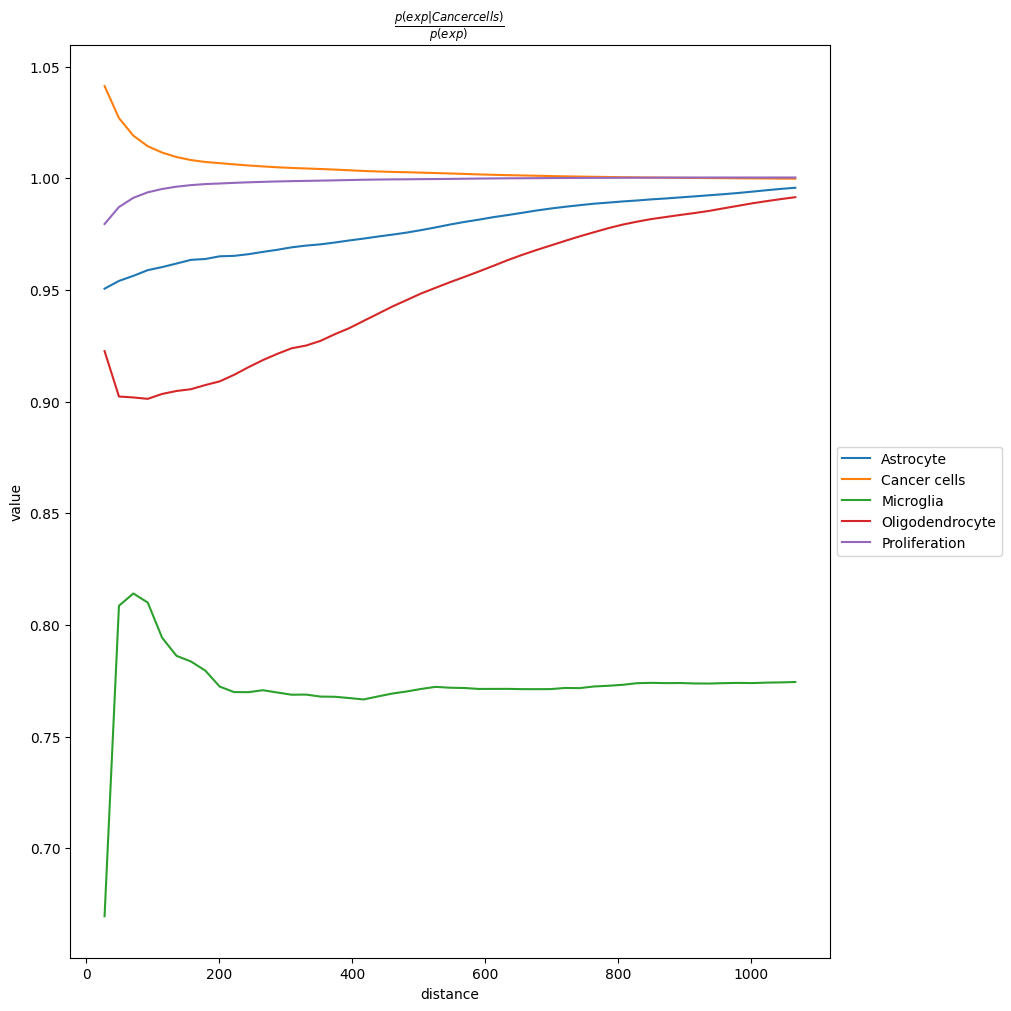

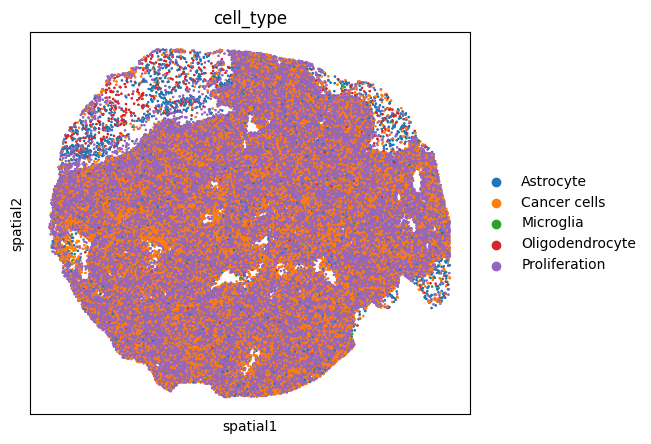

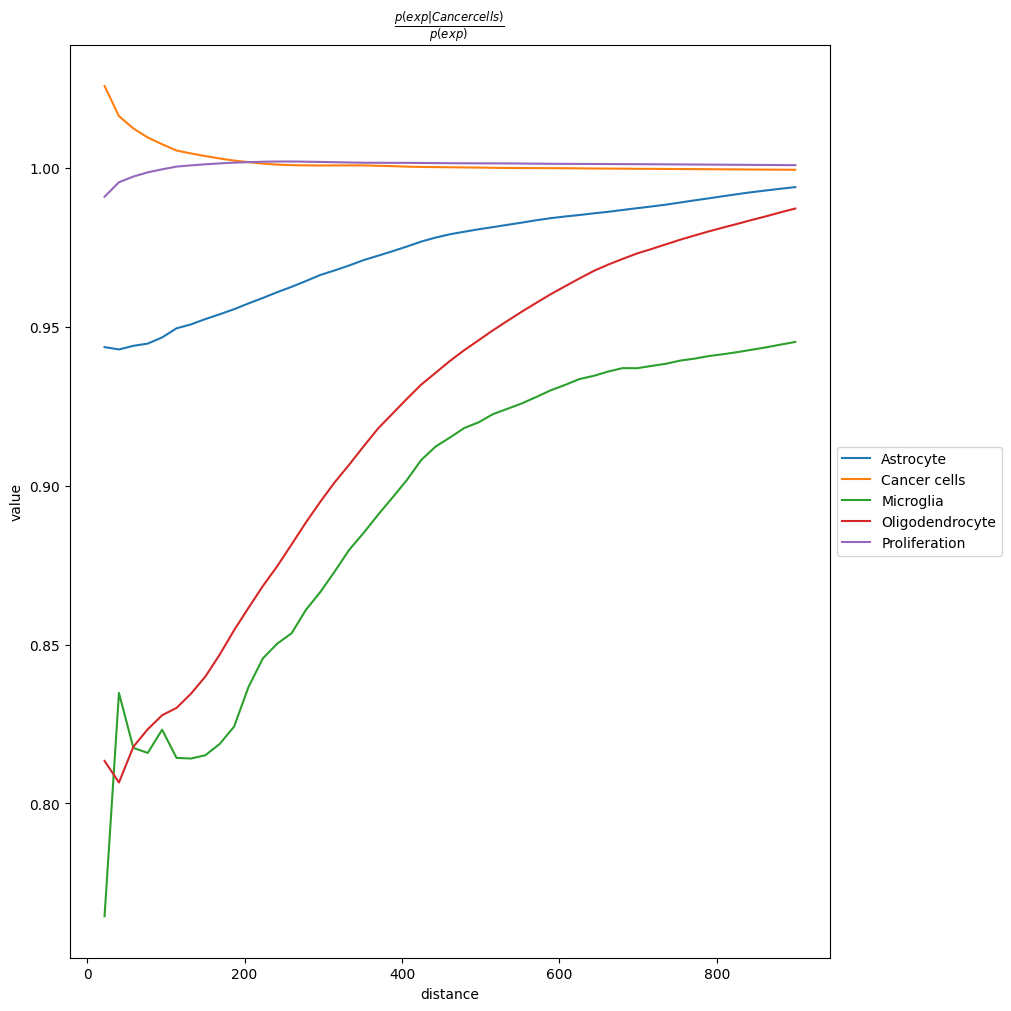

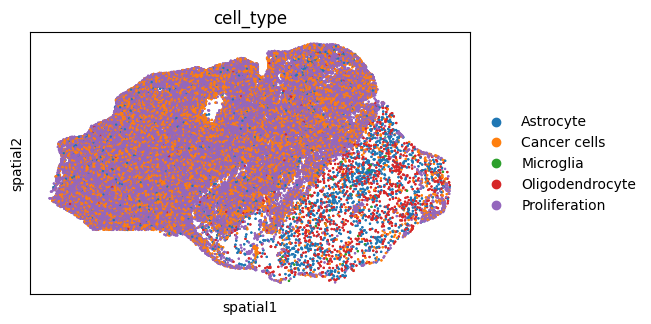

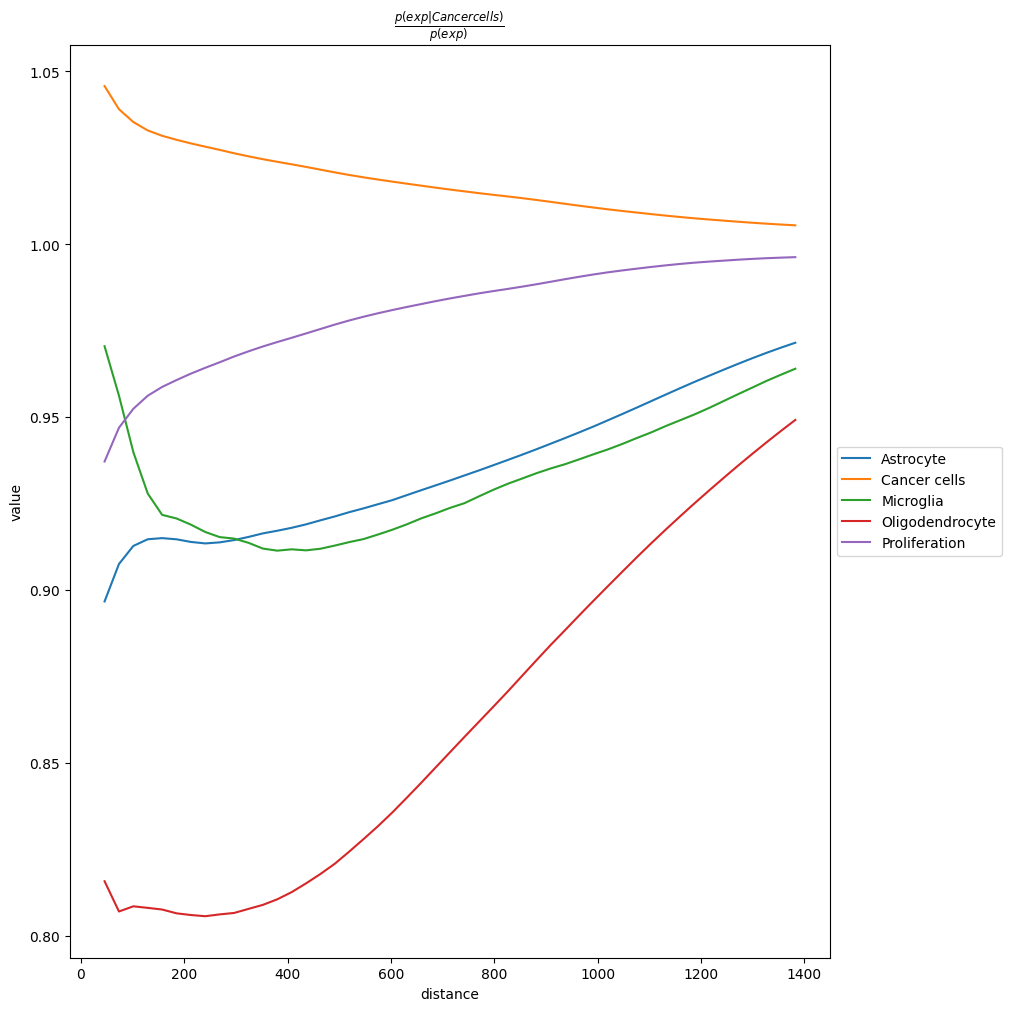

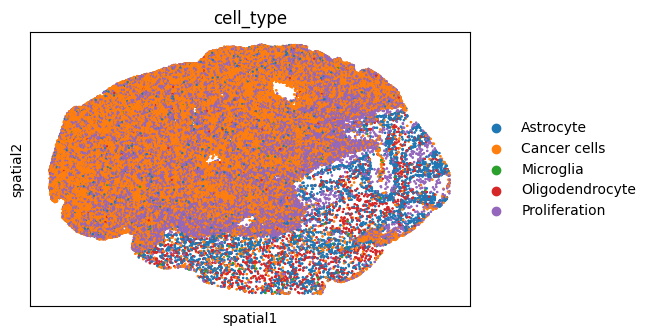

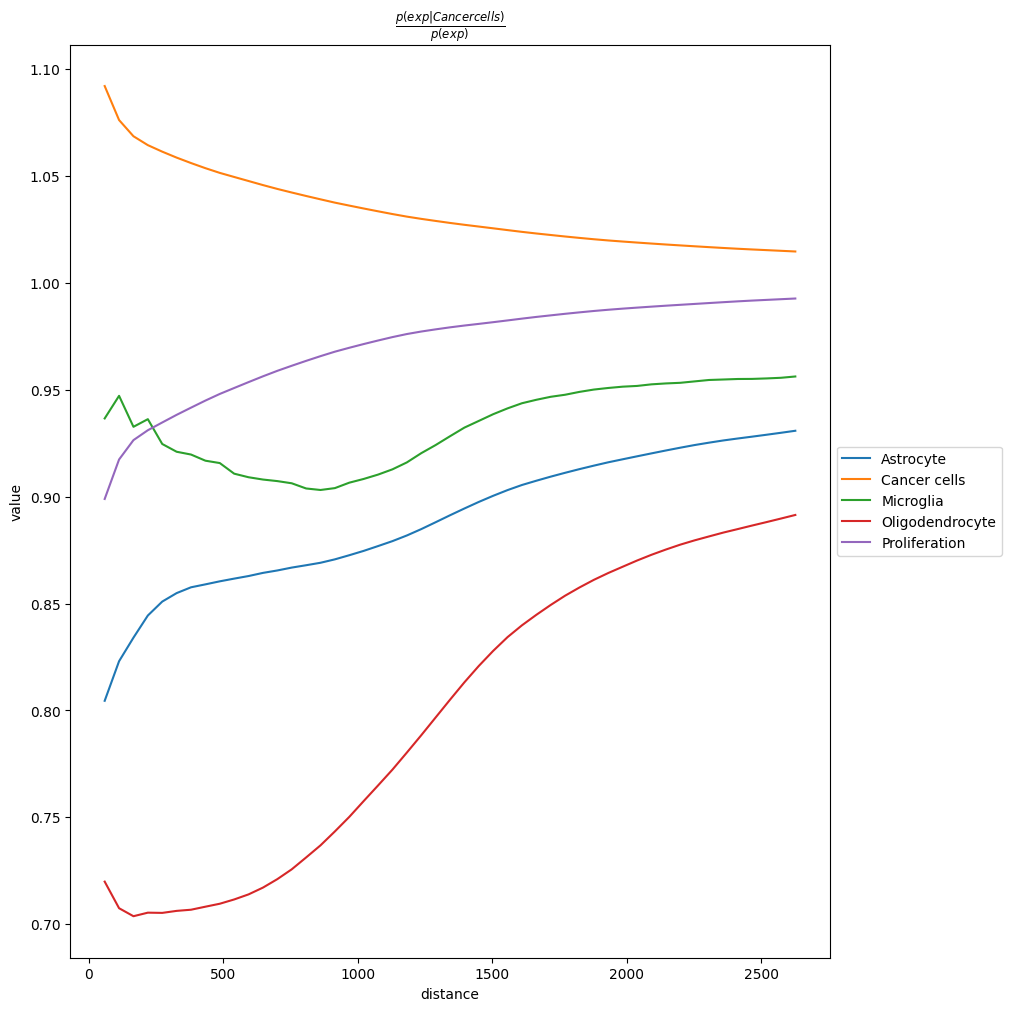

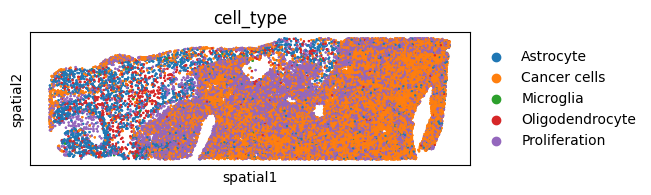

In [15]:
for library_id, adata in MALDI_adata_sub.items():
    # adata.write_h5ad(MALDI_PROCESSED / f"{library_id}_MALDI_adata_dist.h5ad")
    sq.pl.co_occurrence(
        adata,
        cluster_key="cell_type",
        clusters="Cancer cells",
        figsize=(10, 10),
    )
    sq.pl.spatial_scatter(
        adata,
        color="cell_type",
        shape=None,
        size=2,
    )

In [16]:
for library_id, adata in MALDI_adata.items():
    sq.gr.nhood_enrichment(adata, cluster_key="cell_type")
    fig, ax = plt.subplots(1, 2, figsize=(13, 7))
    sq.pl.nhood_enrichment(
        adata,
        cluster_key="cell_type",
        figsize=(8, 8),
        title="Neighborhood enrichment",
        ax=ax[0],
    )
    sq.pl.spatial_scatter(adata, color="cell_type", shape=None, size=2, ax=ax[1])
    fig.savefig(CLS_PATH / f"{library_id}_nhood_enrichment.png")
    plt.close()
    

  0%|          | 0/1000 [00:00<?, ?/s]

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


  0%|          | 0/1000 [00:00<?, ?/s]

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


  0%|          | 0/1000 [00:00<?, ?/s]

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


  0%|          | 0/1000 [00:00<?, ?/s]

/home/uqxtan9/micromamba/envs/spatialdata/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


In [22]:
for library_id, adata in MALDI_adata.items():
    adata.write_h5ad(MALDI_PROCESSED / f"{library_id}_MALDI_adata_dist.h5ad")